In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80,dpi_save=100,color_map='Reds')
sc.logging.print_version_and_date()

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
plt.show()
matplotlib.rcParams.update({'figure.figsize': (6,6)})

Running Scanpy 1.10.3, on 2025-08-19 07:16.


In [3]:
adata_d1_6 = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-bgi-d1-6-rna.h5ad')

In [4]:
adata_d7_10 = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-bgi-d7-10-rna.h5ad')

In [9]:
adata_d1_6.layers['counts'] = adata_d1_6_raw.layers['counts']

In [24]:
adata = ad.concat([adata_d1_6, adata_d7_10], label="batch")

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [27]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:03)


extracting highly variable genes
    finished (0:00:18)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:25)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:34)
running Leiden clustering
    finished: found 26 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


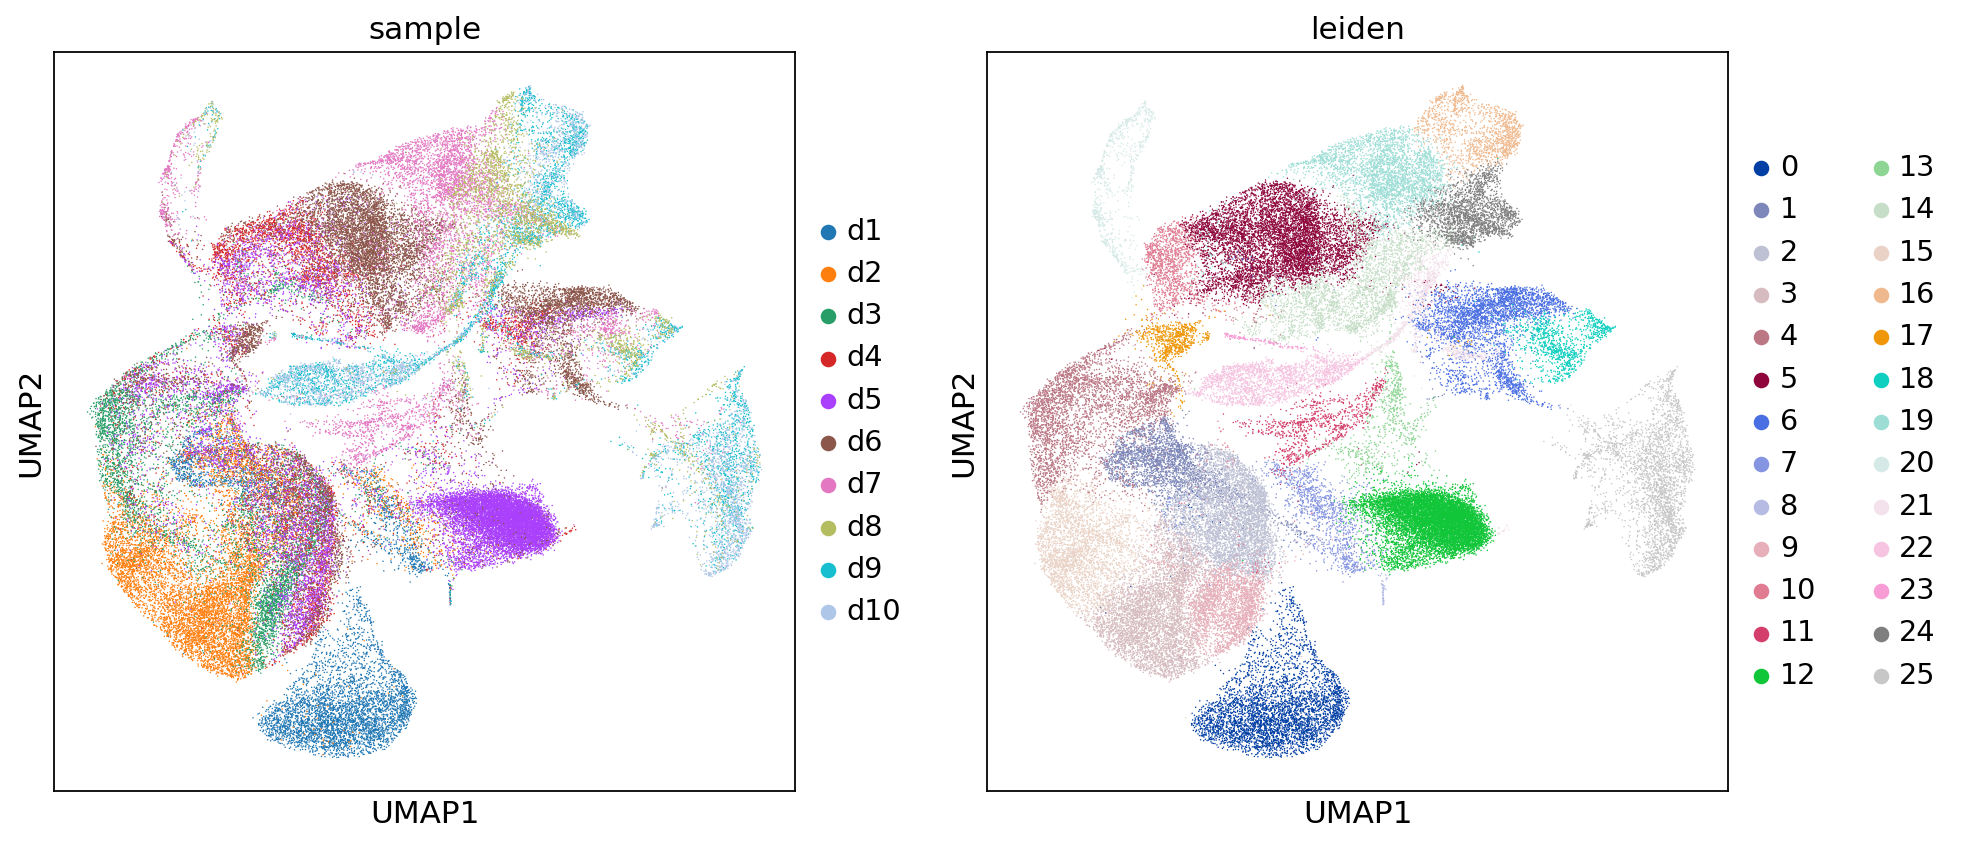

In [28]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata.raw=adata
# adata=adata[:,adata.var['highly_variable']]
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata,color=['sample','leiden'])
# sc.pl.umap(adata,color='celltype',legend_loc='on data',legend_fontsize=6)

In [30]:
%%time
sc.external.pp.bbknn(adata, batch_key="sample")  # running bbknn 1.3.6

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
CPU times: user 16 s, sys: 416 ms, total: 16.4 s
Wall time: 16.3 s


In [31]:
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:40)
running Leiden clustering
    finished: found 20 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)


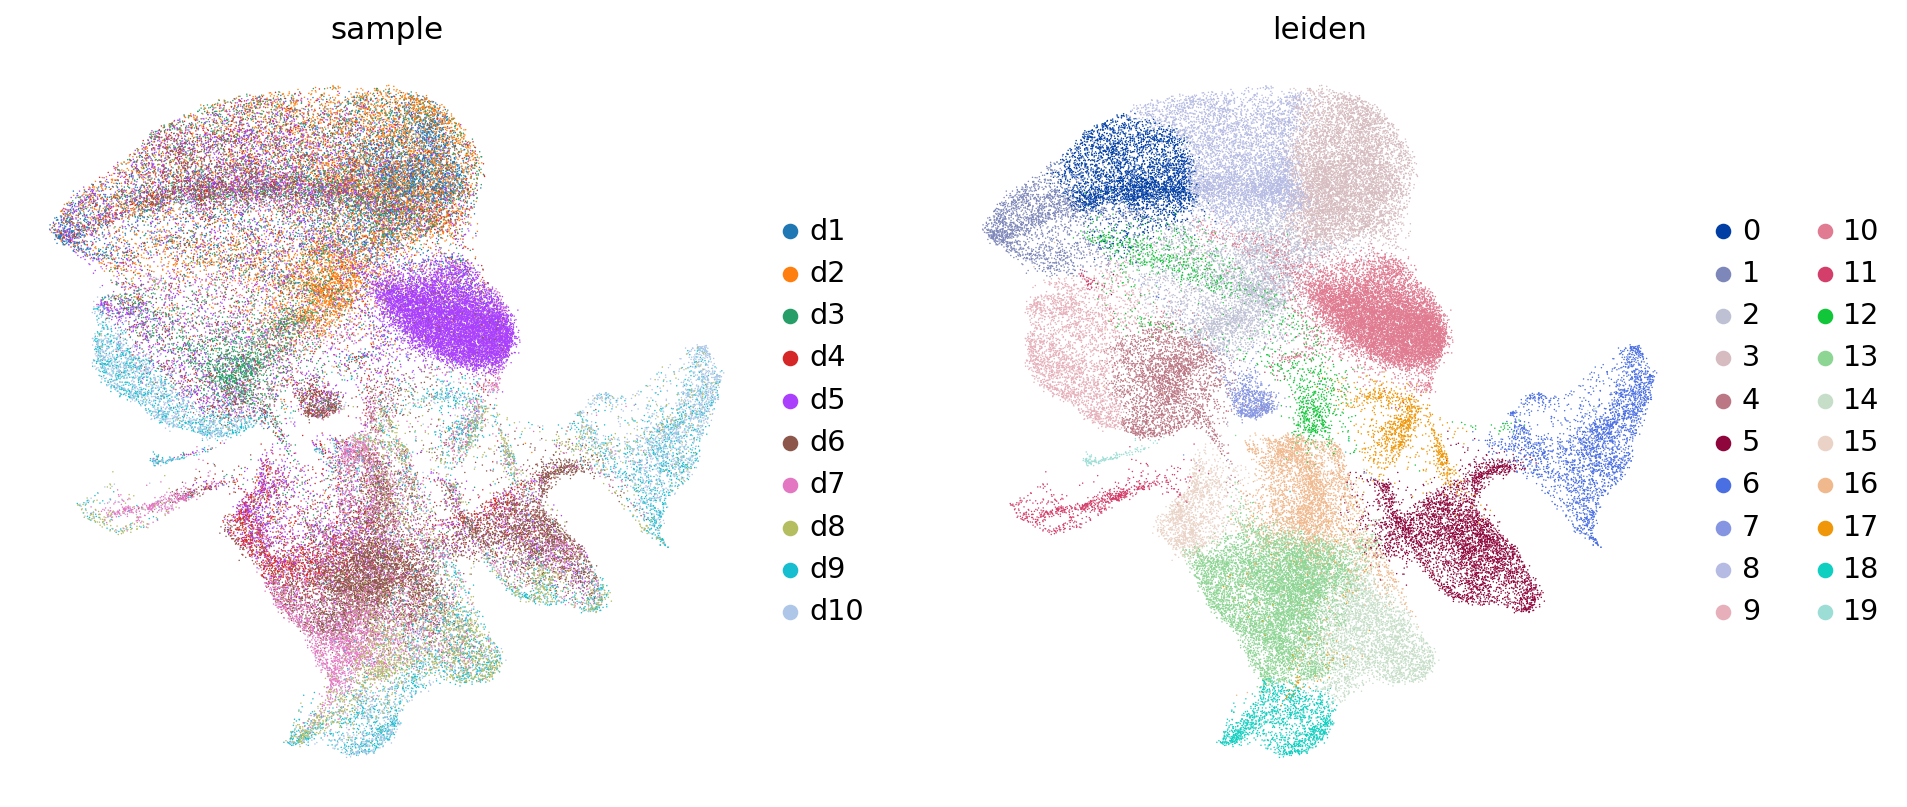

In [37]:
sc.pl.umap(adata, color=["sample", 'leiden'], frameon=False)